In [2]:
import os

# Move to project root if needed
if not os.path.exists("data"):
    os.chdir("..")

print("Current working dir:", os.getcwd())

Current working dir: /Users/guhankesavasamy/Documents/fundops


Project root: /Users/guhankesavasamy/Documents/fundops
Reading: /Users/guhankesavasamy/Documents/fundops/data/processed/features_labeled.parquet

Basic shape:
(5970, 13)

Missing values:
exchange_time       0
midprice            0
spread              0
log_return          1
sigma_future_60s    2
label_spike         0
dtype: int64

Summary statistics:
           midprice       spread   log_return  sigma_future_60s
count   5970.000000  5970.000000  5969.000000       5968.000000
mean   67902.319647     0.255132     0.000001          0.000040
std      246.194711     1.261539     0.000045          0.000019
min    67468.940000     0.010000    -0.000494          0.000012
25%    67632.765000     0.010000     0.000000          0.000026
50%    68017.315000     0.010000     0.000000          0.000037
75%    68103.045000     0.010000     0.000000          0.000046
max    68199.995000    37.950000     0.000826          0.000098

Sigma future 60s quantiles:
0.50    0.000037
0.75    0.000046
0.90    

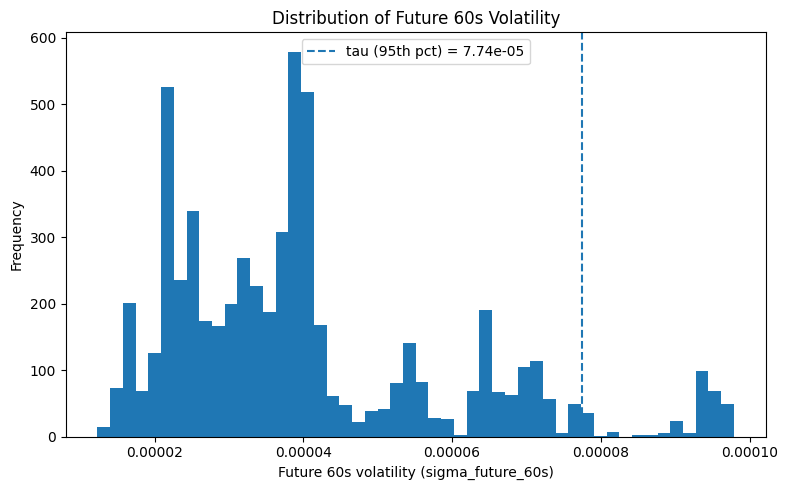

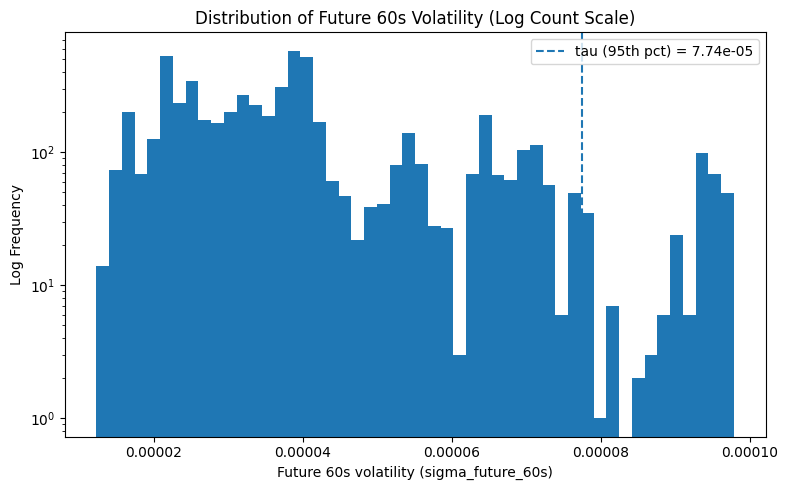

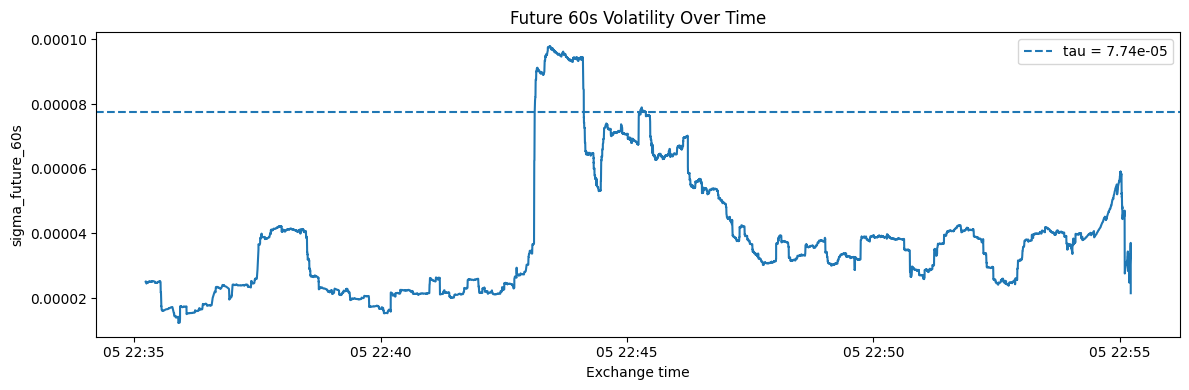

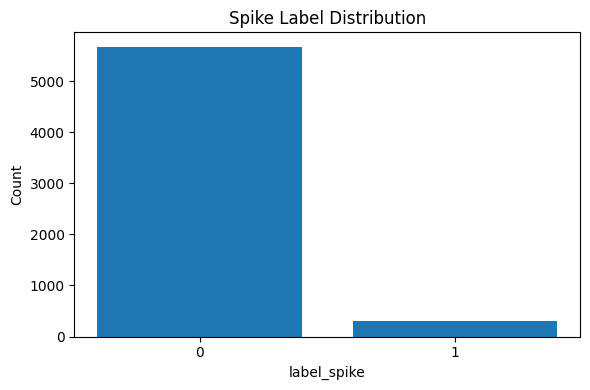

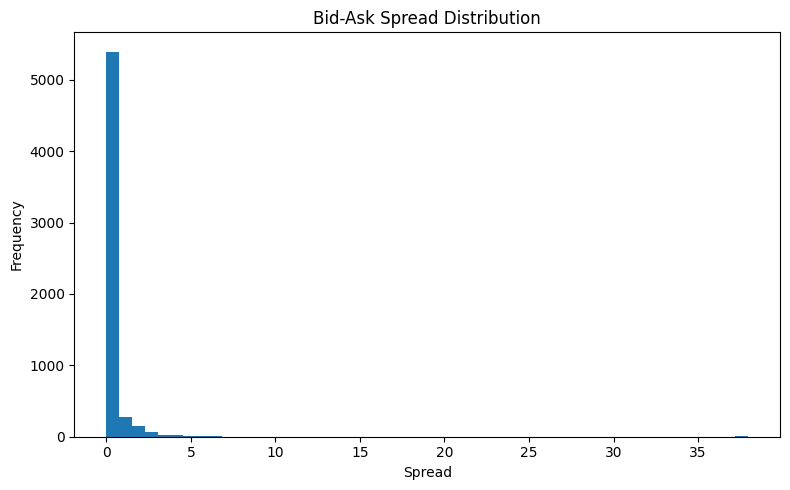

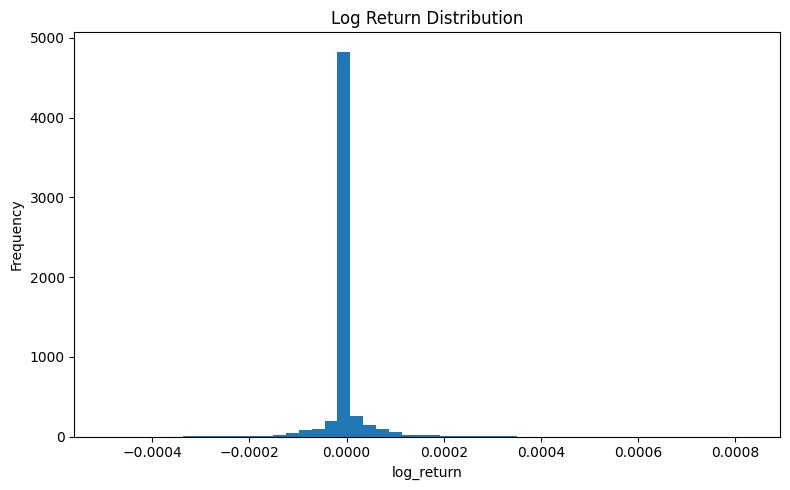


Sigma by label:
              count      mean       std       min       25%       50%  \
label_spike                                                             
0            5669.0  0.000038  0.000015  0.000012  0.000025  0.000037   
1             299.0  0.000092  0.000006  0.000077  0.000091  0.000094   

                  75%       max  
label_spike                      
0            0.000042  0.000077  
1            0.000095  0.000098  

Report-ready observations:
- Total rows: 5970
- Rows with valid future volatility: 5968
- Tau selected at 95th percentile: 0.0000774335
- Positive class count: 299
- Negative class count: 5671
- Positive class percentage: 5.01%
- The future volatility distribution is right-skewed, with most windows having low volatility and a small tail of high-volatility events.
- Choosing tau at the 95th percentile isolates the rare high-volatility windows as spike events.
- This creates an imbalanced but realistic binary classification setting, which supports u

In [3]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# 1. Find project root safely
# ---------------------------
def find_project_root(markers=("data", "scripts", "features")):
    cur = Path.cwd().resolve()
    for p in [cur, *cur.parents]:
        if all((p / m).exists() for m in markers):
            return p
    raise FileNotFoundError("Could not find project root containing data/, scripts/, and features/")

ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "processed" / "features_labeled.parquet"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Reading:", DATA_PATH)

# ---------------------------
# 2. Load and clean data
# ---------------------------
df = pd.read_parquet(DATA_PATH).copy()

df["exchange_time"] = pd.to_datetime(df["exchange_time"], utc=True, errors="coerce")
df["sigma_future_60s"] = pd.to_numeric(df["sigma_future_60s"], errors="coerce")
df["log_return"] = pd.to_numeric(df["log_return"], errors="coerce")
df["spread"] = pd.to_numeric(df["spread"], errors="coerce")
df["midprice"] = pd.to_numeric(df["midprice"], errors="coerce")

df = df.sort_values("exchange_time").reset_index(drop=True)

print("\nBasic shape:")
print(df.shape)

print("\nMissing values:")
print(df[["exchange_time", "midprice", "spread", "log_return", "sigma_future_60s", "label_spike"]].isna().sum())

# ---------------------------
# 3. Summary stats
# ---------------------------
print("\nSummary statistics:")
print(df[["midprice", "spread", "log_return", "sigma_future_60s"]].describe())

quantiles = df["sigma_future_60s"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
tau = quantiles.loc[0.95]

print("\nSigma future 60s quantiles:")
print(quantiles)

print(f"\nChosen tau (95th percentile): {tau:.10f}")

label_dist = df["label_spike"].value_counts(dropna=False).sort_index()
label_ratio = df["label_spike"].value_counts(normalize=True, dropna=False).sort_index()

print("\nLabel counts:")
print(label_dist)

print("\nLabel proportions:")
print(label_ratio)

# ---------------------------
# 4. Plot 1: Sigma histogram
# ---------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["sigma_future_60s"].dropna(), bins=50)
plt.axvline(tau, linestyle="--", label=f"tau (95th pct) = {tau:.2e}")
plt.title("Distribution of Future 60s Volatility")
plt.xlabel("Future 60s volatility (sigma_future_60s)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sigma_hist.png", dpi=200)
plt.show()

# ---------------------------
# 5. Plot 2: Sigma histogram on log-count scale
# ---------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["sigma_future_60s"].dropna(), bins=50, log=True)
plt.axvline(tau, linestyle="--", label=f"tau (95th pct) = {tau:.2e}")
plt.title("Distribution of Future 60s Volatility (Log Count Scale)")
plt.xlabel("Future 60s volatility (sigma_future_60s)")
plt.ylabel("Log Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sigma_hist_logy.png", dpi=200)
plt.show()

# ---------------------------
# 6. Plot 3: Time-series of future volatility
# ---------------------------
plt.figure(figsize=(12, 4))
plt.plot(df["exchange_time"], df["sigma_future_60s"])
plt.axhline(tau, linestyle="--", label=f"tau = {tau:.2e}")
plt.title("Future 60s Volatility Over Time")
plt.xlabel("Exchange time")
plt.ylabel("sigma_future_60s")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "sigma_over_time.png", dpi=200)
plt.show()

# ---------------------------
# 7. Plot 4: Label balance
# ---------------------------
counts = df["label_spike"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Spike Label Distribution")
plt.xlabel("label_spike")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "label_distribution.png", dpi=200)
plt.show()

# ---------------------------
# 8. Plot 5: Spread distribution
# ---------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["spread"].dropna(), bins=50)
plt.title("Bid-Ask Spread Distribution")
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "spread_hist.png", dpi=200)
plt.show()

# ---------------------------
# 9. Plot 6: Log return distribution
# ---------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["log_return"].dropna(), bins=50)
plt.title("Log Return Distribution")
plt.xlabel("log_return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIG_DIR / "log_return_hist.png", dpi=200)
plt.show()

# ---------------------------
# 10. Positive vs negative class sigma comparison
# ---------------------------
print("\nSigma by label:")
print(df.groupby("label_spike")["sigma_future_60s"].describe())

# ---------------------------
# 11. Simple report-ready observations
# ---------------------------
num_rows = len(df)
num_valid_sigma = df["sigma_future_60s"].notna().sum()
num_positive = int((df["label_spike"] == 1).sum())
num_negative = int((df["label_spike"] == 0).sum())
positive_pct = 100 * num_positive / (num_positive + num_negative)

print("\nReport-ready observations:")
print(f"- Total rows: {num_rows}")
print(f"- Rows with valid future volatility: {num_valid_sigma}")
print(f"- Tau selected at 95th percentile: {tau:.10f}")
print(f"- Positive class count: {num_positive}")
print(f"- Negative class count: {num_negative}")
print(f"- Positive class percentage: {positive_pct:.2f}%")
print("- The future volatility distribution is right-skewed, with most windows having low volatility and a small tail of high-volatility events.")
print("- Choosing tau at the 95th percentile isolates the rare high-volatility windows as spike events.")
print("- This creates an imbalanced but realistic binary classification setting, which supports using PR-AUC as the main evaluation metric.")
print(f"\nSaved figures to: {FIG_DIR}")

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Ensure directory exists
os.makedirs("reports/figures", exist_ok=True)

df = pd.read_parquet("data/processed/features_labeled.parquet")

# 1. Sigma distribution
plt.figure()
df["sigma_future_60s"].hist(bins=50)
plt.title("Future Volatility Distribution")
plt.xlabel("Sigma (60s)")
plt.ylabel("Frequency")
plt.savefig("reports/figures/sigma_hist.png", dpi=200)
plt.close()

# 2. Log-scale histogram
plt.figure()
df["sigma_future_60s"].hist(bins=50, log=True)
plt.title("Future Volatility Distribution (Log Scale)")
plt.xlabel("Sigma (60s)")
plt.ylabel("Log Frequency")
plt.savefig("reports/figures/sigma_hist_log.png", dpi=200)
plt.close()

# 3. Time series
plt.figure(figsize=(10,4))
df["sigma_future_60s"].plot()
plt.title("Future Volatility Over Time")
plt.xlabel("Time")
plt.ylabel("Sigma")
plt.savefig("reports/figures/sigma_time.png", dpi=200)
plt.close()

# 4. Label distribution
plt.figure()
df["label_spike"].value_counts().plot(kind="bar")
plt.title("Spike Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.savefig("reports/figures/label_dist.png", dpi=200)
plt.close()

# 5. Spread distribution
plt.figure()
df["spread"].hist(bins=50)
plt.title("Bid-Ask Spread Distribution")
plt.xlabel("Spread")
plt.ylabel("Frequency")
plt.savefig("reports/figures/spread_hist.png", dpi=200)
plt.close()

# 6. Log return distribution
plt.figure()
df["log_return"].dropna().hist(bins=50)
plt.title("Log Return Distribution")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.savefig("reports/figures/log_return_hist.png", dpi=200)
plt.close()

print("All figures saved to reports/figures/")

All figures saved to reports/figures/


Visualization and Threshold Selection

We analyze the distribution of future volatility, defined as the standard deviation of log returns over a 60-second horizon.

The distribution of sigma_future_60s is strongly right-skewed, as shown in the histogram. Most observations are concentrated at low volatility levels, while a small number of observations form a long tail corresponding to high-volatility events. This behavior is further confirmed using a log-scale histogram, which highlights the presence of rare but significant spikes.

Based on this distribution, we select the spike threshold 
𝜏
τ as the 95th percentile of the volatility values:

𝜏
=
7.74
×
10
−
5
τ=7.74×10
−5

This choice ensures that only the top 5% of the most volatile windows are labeled as spikes.

Label Distribution

Using this threshold, we obtain the following label distribution:

Non-spike (0): 5671 samples (~95%)
Spike (1): 299 samples (~5%)

This results in a naturally imbalanced classification problem, which is expected for volatility spike detection tasks.

Class-wise Volatility Analysis

We further compare volatility across classes:

Mean volatility for non-spike events: 
≈
3.8
×
10
−
5
≈3.8×10
−5
Mean volatility for spike events: 
≈
9.2
×
10
−
5
≈9.2×10
−5

This shows a clear separation between the two classes, indicating that the selected threshold effectively captures high-volatility events.

Observations
The volatility distribution is right-skewed with a long tail.
The 95th percentile threshold successfully isolates extreme volatility events.
The resulting dataset is imbalanced but realistic for anomaly detection.
The separation between classes suggests that predictive modeling is feasible.